In [6]:
# Run this cell twice (for loading the mplhep setting)
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

In [2]:
## Uncomment the option to use

## Loading the original tree
# tree = uproot.open("/eos/user/a/atarabin/photonID/samples/hadded.root:ntuplizer/tree")
# df = tree.arrays(library="pd")
# fromPandas = False

## Loading the saved pandas
df = pd.read_parquet("SimpleBinaryClassification_XGBoost/dfPostReweighting.parquet", engine="pyarrow")  # Using pyarrow
fromPandas = True

In [11]:
## Endcap
var_min_EE = {
    'pT': 10,
    'pho_SCEta': -2.5,
    'pho_SCEtaWidth': 0,
    'pho_R9Full5x5': 0.4,
    'pho_S4': 0.2,
    'pho_SigmaIEtaIPhiFull5x5': -0.001,
    'pho_SigmaIEtaIEtaFull5x5': 0
}
var_max_EE = {
    'pT': 150,
    'pho_SCEta': 2.5,
    'pho_SCEtaWidth': 0.06,
    'pho_R9Full5x5': 1.2,
    'pho_S4': 1,
    'pho_SigmaIEtaIPhiFull5x5': 0.001,
    'pho_SigmaIEtaIEtaFull5x5': 0.06
}

## Barrel
var_min_EB = {
    'pT': 10,
    'pho_SCEta': -1.442,
    'pho_SCEtaWidth': 0,
    'pho_R9Full5x5': 0.4,
    'pho_S4': 0.2,
    'pho_SigmaIEtaIPhiFull5x5': -0.0003,
    'pho_SigmaIEtaIEtaFull5x5': 0
}
var_max_EB = {
    'pT': 150,
    'pho_SCEta': 1.442,
    'pho_SCEtaWidth': 0.02,
    'pho_R9Full5x5': 1.2,
    'pho_S4': 1,
    'pho_SigmaIEtaIPhiFull5x5': 0.0003,
    'pho_SigmaIEtaIEtaFull5x5': 0.02
}

## Labels
label = {
    'pT': r'$p_T$',
    'pho_SCEta': r'$\eta_{SC}$',
    'pho_SCEtaWidth': r'$\sigma_\eta$',
    'pho_R9Full5x5': 'R9',
    'pho_S4': r'$E_{2x2}/E_{5x5}$',
    'pho_SigmaIEtaIPhiFull5x5': r'$\sigma_{i\eta i\phi}$',
    'pho_SigmaIEtaIEtaFull5x5': r'$\sigma_{i\eta i\eta}$'
}

kin_cut = (df["pT"] > 10) & ((abs(df["pho_SCEta"]) < 1.442) | (abs(df["pho_SCEta"]) > 1.566)) & (abs(df["pho_SCEta"]) < 2.5)
nbins = 80

In [4]:
def equal_population_bins(data, n_bins):
    """
    Compute bin edges such that each bin contains (approximately) the same number of data points.
    
    Parameters:
    - data (array-like): Input data array
    - n_bins (int): Number of bins
    
    Returns:
    - bin_edges (array): The bin edges
    """
    return np.quantile(data, np.linspace(0, 1, n_bins + 1))


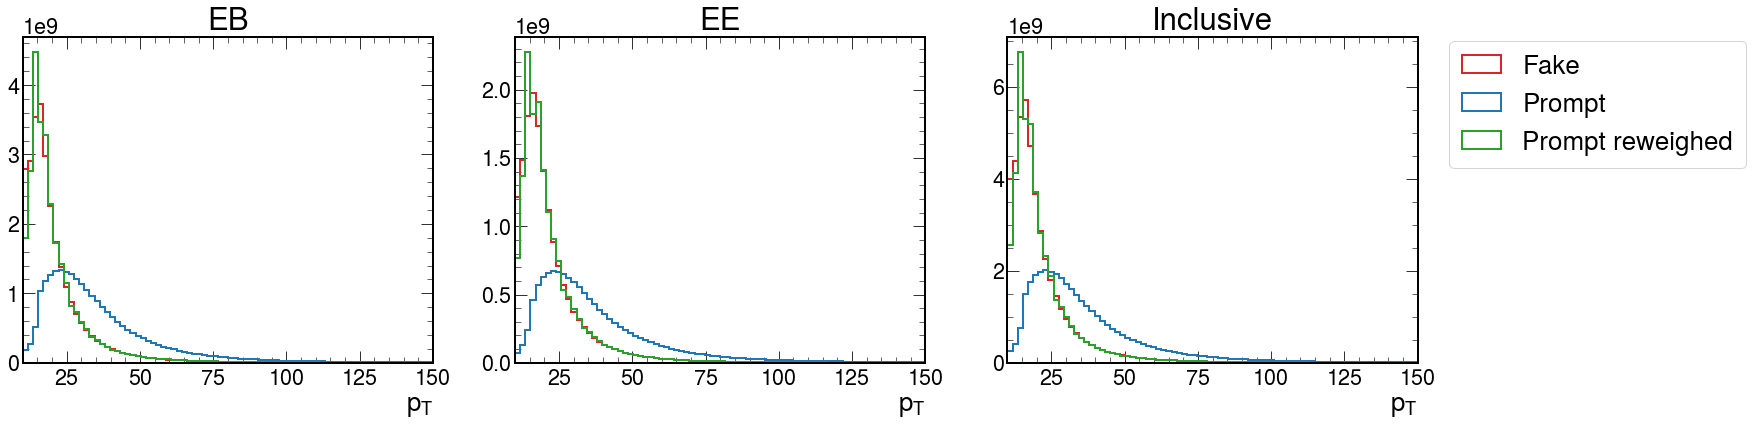

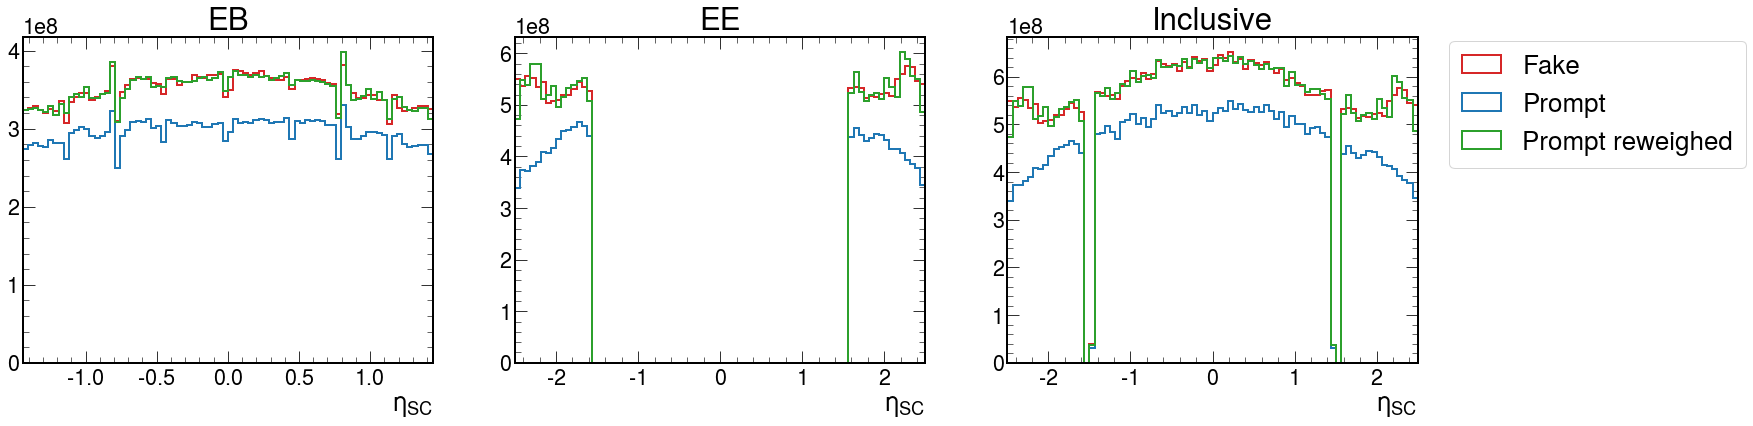

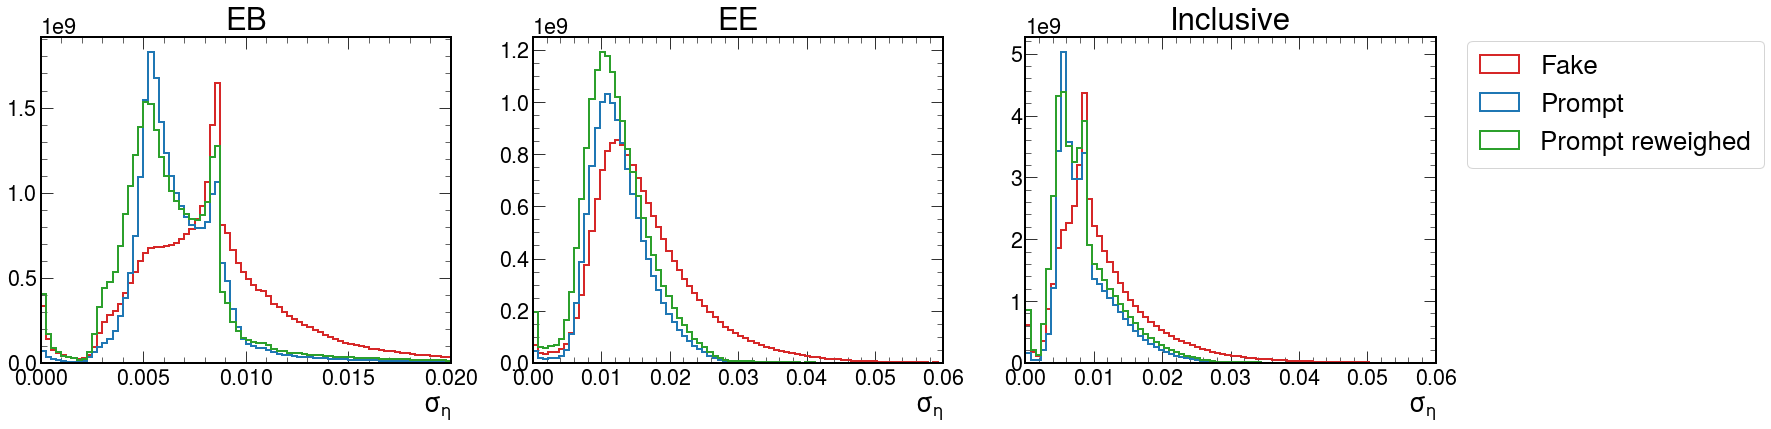

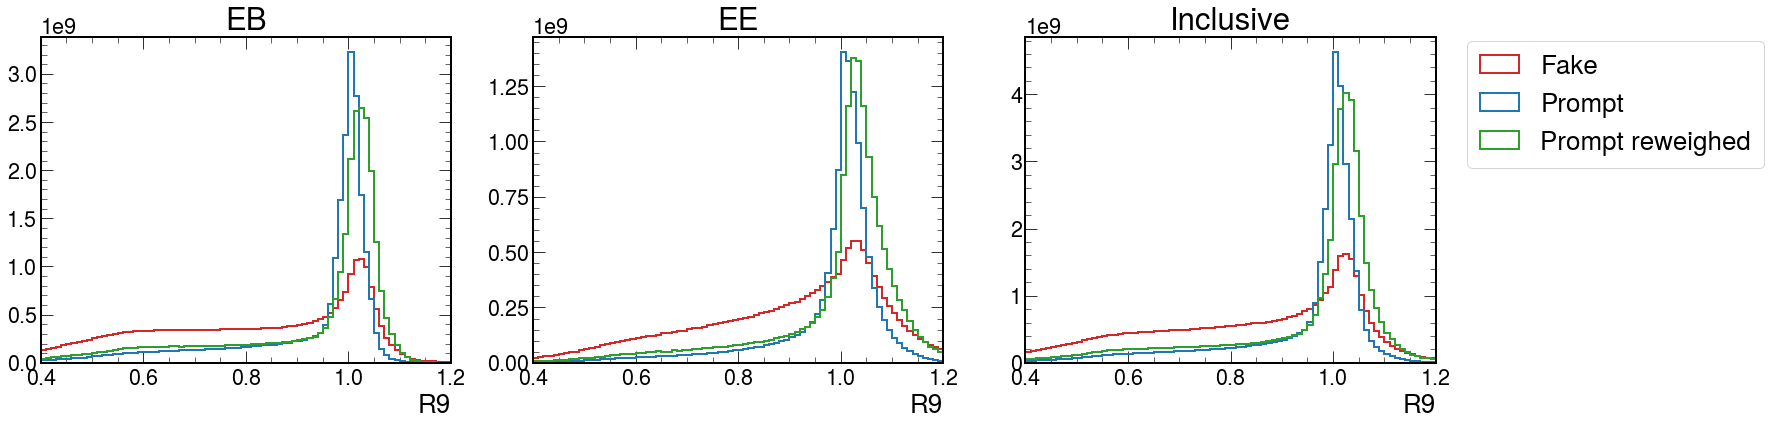

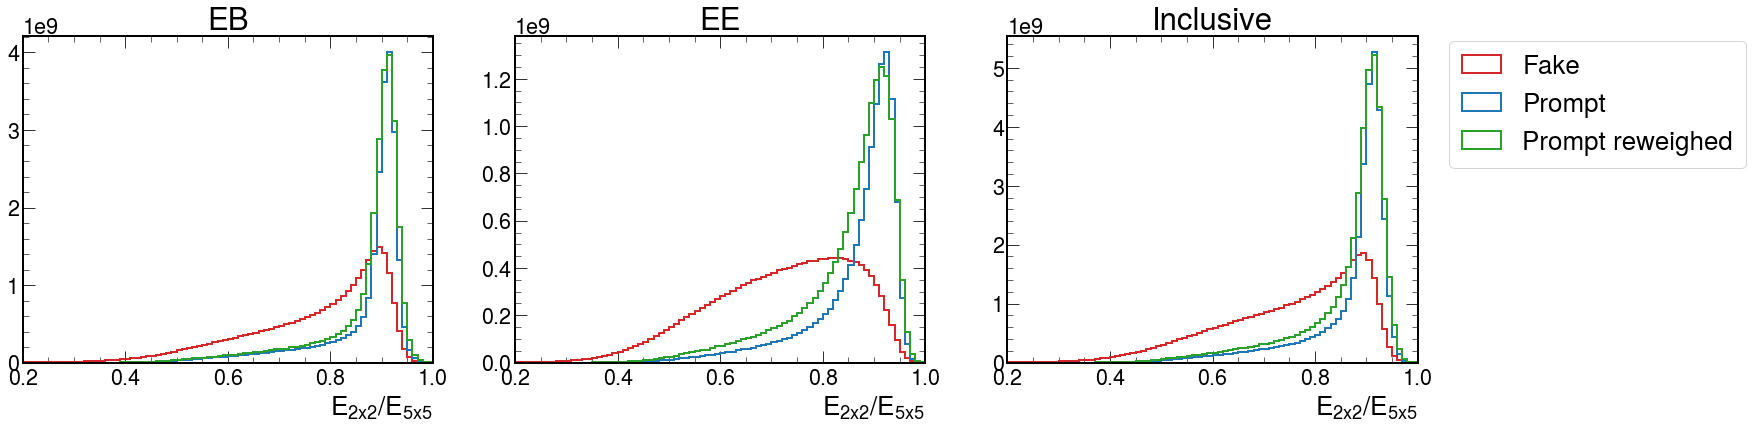

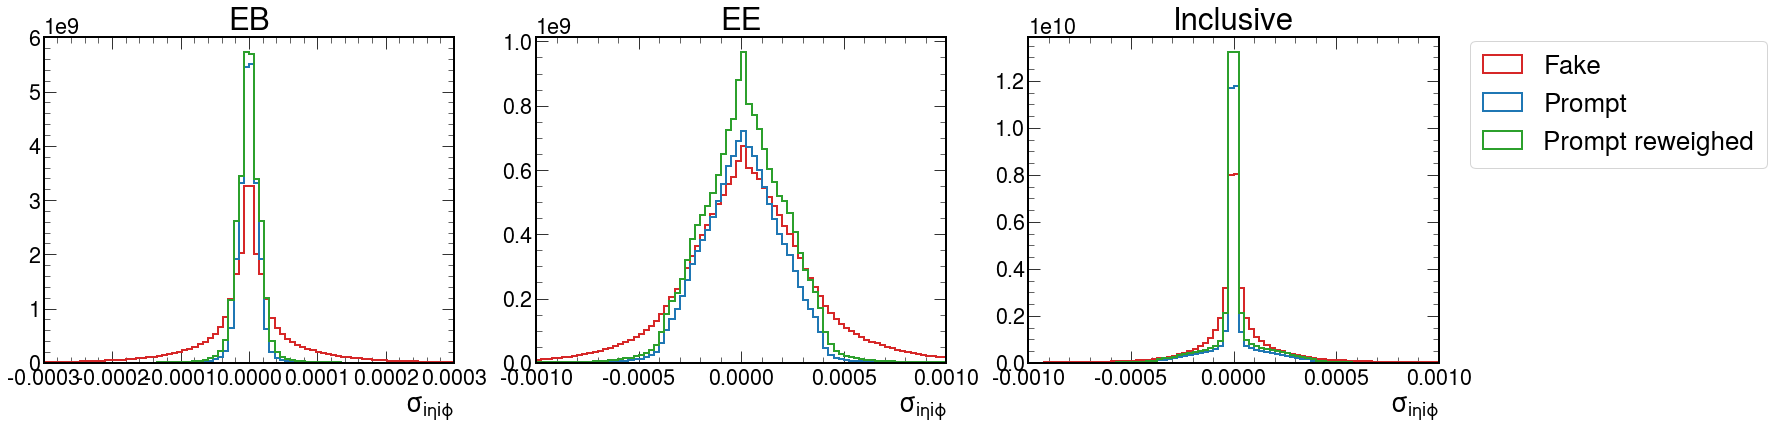

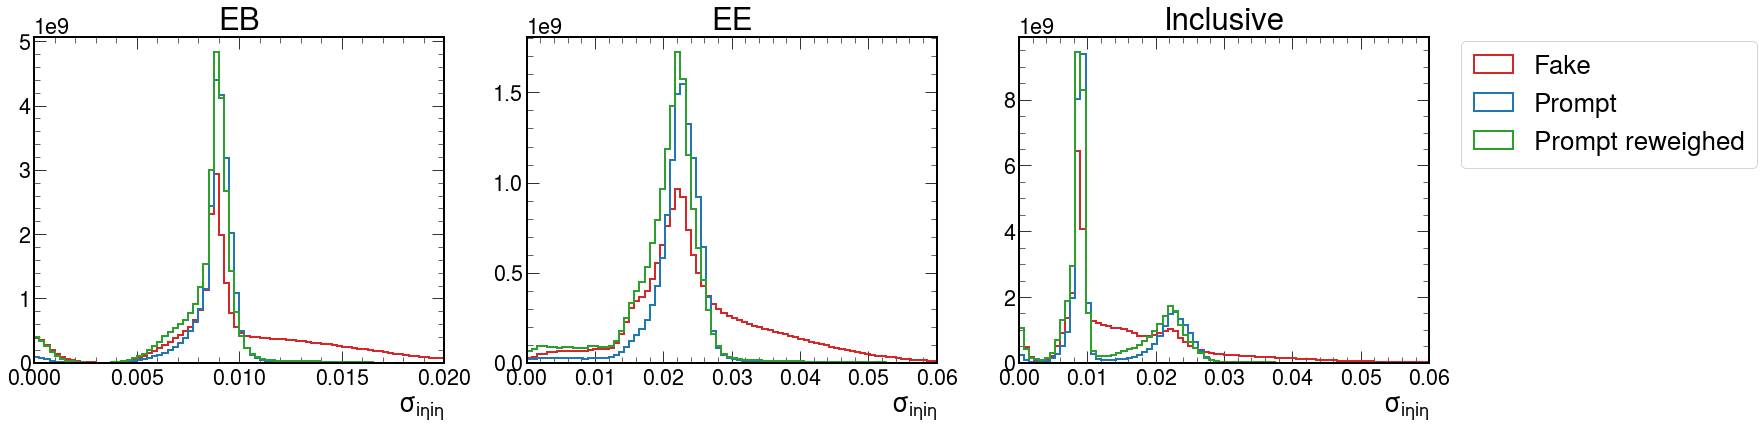

In [14]:
for var in label:
    var_cut_EB = (df[var]>var_min_EB[var]) & (df[var]<var_max_EB[var])
    var_cut_EE = (df[var]>var_min_EE[var]) & (df[var]<var_max_EE[var])

    ## Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 6))

    ax1.set_title("EB")
    ax1.hist(
        df[var][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))], 
        bins=nbins, label="Fake", histtype="step", linewidth=2, color="tab:red", ls='-', range=(var_min_EB[var], var_max_EB[var]),
        weights=df['xs'][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))]
    )
    ax1.hist(
        df[var][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & (df.matchedToGenPh==1)], 
        bins=nbins, label="Prompt", histtype="step", linewidth=2, color="tab:blue", ls='-', range=(var_min_EB[var], var_max_EB[var]),
        weights=df['xs'][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & (df.matchedToGenPh==1)]
    )
    if fromPandas:
        ax1.hist(
            df[var][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & (df.matchedToGenPh==1)], 
            bins=nbins, label="Prompt reweighed", histtype="step", linewidth=2, color="tab:green", ls='-', range=(var_min_EB[var], var_max_EB[var]), 
            weights=df['NewWt'][(abs(df["pho_SCEta"])<1.442) & kin_cut & var_cut_EB & (df.matchedToGenPh==1)]
        )
    ax1.set_xlim(var_min_EB[var], var_max_EB[var])
    ax1.set_xlabel(label[var])

    ax2.set_title("EE")
    ax2.hist(
        df[var][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))], 
        bins=nbins, label="Fake", histtype="step", linewidth=2, color="tab:red", ls='-', range=(var_min_EE[var], var_max_EE[var]),
        weights=df['xs'][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))]
    )
    ax2.hist(
        df[var][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & (df.matchedToGenPh==1)], 
        bins=nbins, label="Prompt", histtype="step", linewidth=2, color="tab:blue", ls='-', range=(var_min_EE[var], var_max_EE[var]),
        weights=df['xs'][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & (df.matchedToGenPh==1)]
    )
    if fromPandas:
        ax2.hist(
            df[var][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & (df.matchedToGenPh==1)], 
            bins=nbins, label="Prompt reweighed", histtype="step", linewidth=2, color="tab:green", ls='-', range=(var_min_EE[var], var_max_EE[var]), 
            weights=df['NewWt'][(abs(df["pho_SCEta"])>1.566) & kin_cut & var_cut_EE & (df.matchedToGenPh==1)]
        )
    ax2.set_xlim(var_min_EE[var], var_max_EE[var])
    ax2.set_xlabel(label[var])
    
    ax3.set_title("Inclusive")
    ax3.hist(
        df[var][kin_cut & var_cut_EE & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))], 
        bins=nbins, label="Fake", histtype="step", linewidth=2, color="tab:red", ls='-', range=(var_min_EE[var], var_max_EE[var]),
        weights=df['xs'][kin_cut & var_cut_EE & ((df.matchedToGenPh==0) | (df.matchedToGenPh==2))]
    )
    ax3.hist(
        df[var][kin_cut & var_cut_EE & (df.matchedToGenPh==1)], 
        bins=nbins, label="Prompt", histtype="step", linewidth=2, color="tab:blue", ls='-', range=(var_min_EE[var], var_max_EE[var]),
        weights=df['xs'][kin_cut & var_cut_EE & (df.matchedToGenPh==1)]
    )
    if fromPandas:
        ax3.hist(
            df[var][kin_cut & var_cut_EE & (df.matchedToGenPh==1)], 
            bins=nbins, label="Prompt reweighed", histtype="step", linewidth=2, color="tab:green", ls='-', range=(var_min_EE[var], var_max_EE[var]), 
            weights=df['NewWt'][kin_cut & var_cut_EE & (df.matchedToGenPh==1)]
        )
    ax3.set_xlim(var_min_EE[var], var_max_EE[var])
    ax3.set_xlabel(label[var])

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(1.0, 0.9), ncol=1, fontsize='medium', frameon=True)

    plt.show()